In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from sklearn.metrics import (confusion_matrix, classification_report, 
                              ConfusionMatrixDisplay)

print("Imports successful ✓")

Imports successful ✓


In [2]:
model = load_model("../models/pehchan_model.keras")

X_test  = np.load("../models/X_test.npy")
yg_test = np.load("../models/yg_test.npy")
ya_test = np.load("../models/ya_test.npy")

print(f"Model loaded ✓")
print(f"Test samples: {len(X_test)}")

Model loaded ✓
Test samples: 4742


In [3]:
gender_pred, age_pred = model.predict(X_test)

# Convert predictions to class labels
gender_pred_labels = (gender_pred > 0.5).astype(int).flatten()
age_pred_labels = np.argmax(age_pred, axis=1)

print("Predictions done ✓")

149/149 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step
Predictions done ✓


In [4]:
gender_names = ["Male", "Female"]
age_names = ["Child (0-12)", "Teen (13-19)", "Young Adult (20-35)", 
             "Adult (36-55)", "Senior (56+)"]

print("=" * 45)
print("GENDER PREDICTION REPORT")
print("=" * 45)
print(classification_report(yg_test, gender_pred_labels, 
                             target_names=gender_names))

GENDER PREDICTION REPORT
              precision    recall  f1-score   support

        Male       0.90      0.91      0.91      2485
      Female       0.90      0.89      0.90      2257

    accuracy                           0.90      4742
   macro avg       0.90      0.90      0.90      4742
weighted avg       0.90      0.90      0.90      4742



In [6]:
print("=" * 45)
print("AGE GROUP PREDICTION REPORT")
print("=" * 45)
print(classification_report(ya_test, age_pred_labels, 
                             target_names=age_names))

AGE GROUP PREDICTION REPORT
                     precision    recall  f1-score   support

       Child (0-12)       0.92      0.90      0.91       675
       Teen (13-19)       0.43      0.25      0.31       211
Young Adult (20-35)       0.75      0.90      0.82      2116
      Adult (36-55)       0.53      0.55      0.54      1032
       Senior (56+)       0.87      0.44      0.58       708

           accuracy                           0.73      4742
          macro avg       0.70      0.61      0.63      4742
       weighted avg       0.73      0.73      0.71      4742



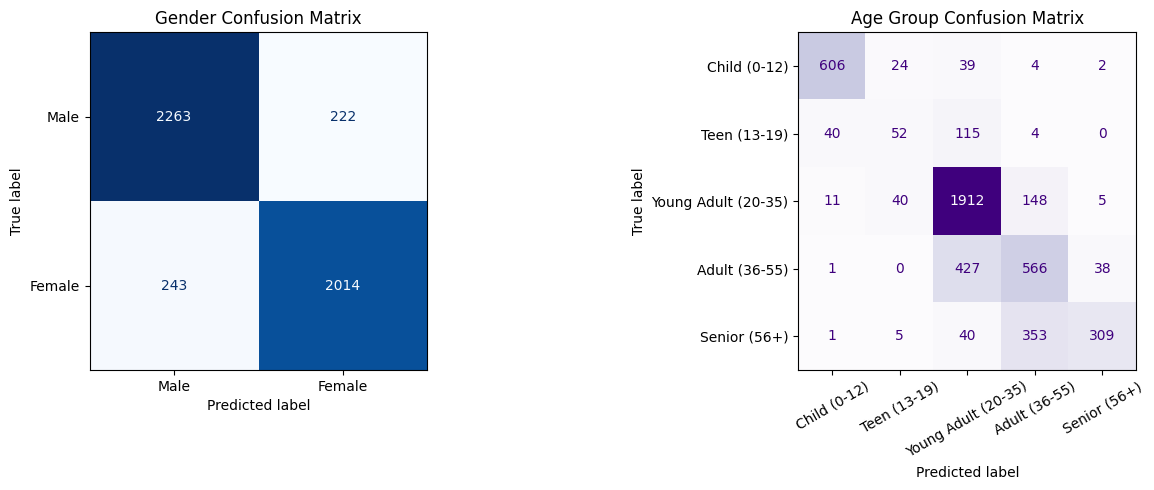

Evaluation saved ✓


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender confusion matrix
cm_gender = confusion_matrix(yg_test, gender_pred_labels)
disp1 = ConfusionMatrixDisplay(cm_gender, display_labels=gender_names)
disp1.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Gender Confusion Matrix")

# Age confusion matrix
cm_age = confusion_matrix(ya_test, age_pred_labels)
disp2 = ConfusionMatrixDisplay(cm_age, display_labels=age_names)
disp2.plot(ax=axes[1], colorbar=False, cmap="Purples")
axes[1].set_title("Age Group Confusion Matrix")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("../evaluation_results.png")
plt.show()
print("Evaluation saved ✓")

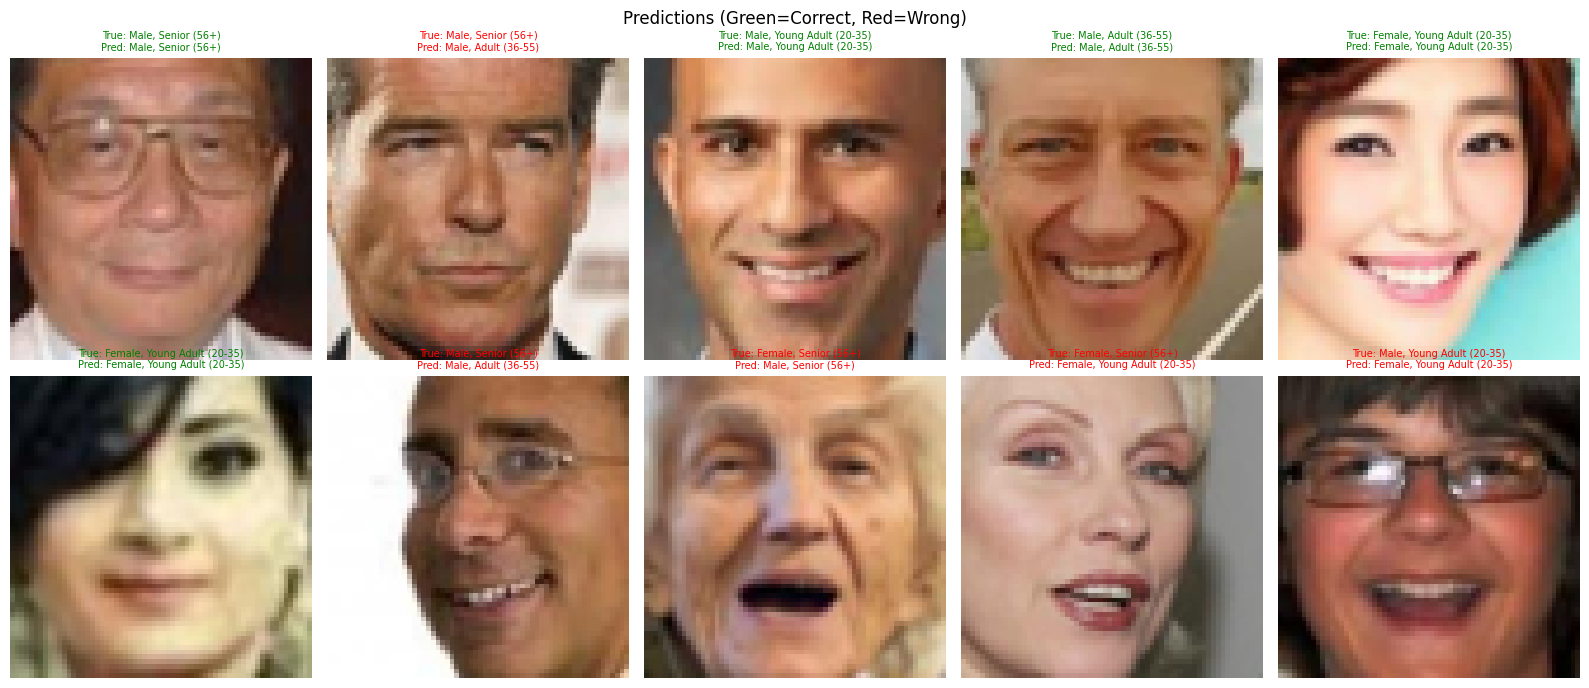

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
indices = np.random.choice(len(X_test), 10, replace=False)

for ax, idx in zip(axes.flatten(), indices):
    img = X_test[idx]
    true_gender = gender_names[yg_test[idx]]
    true_age    = age_names[ya_test[idx]]

    pred_g = gender_names[gender_pred_labels[idx]]
    pred_a = age_names[age_pred_labels[idx]]

    correct = (pred_g == true_gender) and (pred_a == true_age)
    color = "green" if correct else "red"

    ax.imshow(img)
    ax.set_title(
        f"True: {true_gender}, {true_age}\nPred: {pred_g}, {pred_a}",
        fontsize=7, color=color
    )
    ax.axis("off")

plt.suptitle("Predictions (Green=Correct, Red=Wrong)", fontsize=12)
plt.tight_layout()
plt.savefig("../prediction_samples.png")
plt.show()